In [10]:
import torch
import torch.nn as nn
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import time
from collections import OrderedDict

a = 0.1 
b = 1    
c = 0.3  
k = np.sqrt(a / (2 * (c**2 - a**2))) 

nu = 0.1

In [11]:
def analytical_solution(t, x):
    u = torch.sqrt(torch.tensor(a/b)) * torch.tanh(k * (x - c * t))
    return u.reshape(-1, 1)

def analytical_solution_v(t, x):
    sech_term = 1.0 / torch.cosh(k * (x - c * t))
    v = -c * torch.sqrt(torch.tensor(a/b)) * k * (sech_term ** 2)
    return v.reshape(-1, 1)

def initial_condition_u(x):
    return torch.sqrt(torch.tensor(a/b)) * torch.tanh(k * x)

def initial_condition_v(x):
    sech_term = 1.0 / torch.cosh(k * x)
    return -c * torch.sqrt(torch.tensor(a/b)) * k * (sech_term ** 2)

In [12]:
class PINN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(PINN, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.linear3 = nn.Linear(hidden_size, hidden_size)
        self.linear4 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 2) 
        self.tanh = nn.Tanh()
        self.iter = 0

    def forward(self, x, t=None):
        if t is not None:
            inputs = torch.cat([t, x], dim=1)
        else:
            inputs = x
            
        out = self.linear1(inputs)
        out = self.tanh(out)
        out = self.linear2(out)
        out = self.tanh(out)
        out = self.linear3(out)
        out = self.tanh(out)
        out = self.linear4(out)
        out = self.tanh(out)
        out = self.output(out)
        return out 

In [13]:
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        self.lb = torch.tensor(lb).float()
        self.ub = torch.tensor(ub).float()

        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float()
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float()
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        self.dnn = DNN(layers)

        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, u, t, x):

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        u_tt = torch.autograd.grad(
            u_t, t,
            grad_outputs=torch.ones_like(u_t),
            retain_graph=True,
            create_graph=True
        )[0]

        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True
        )[0]

        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True
        )[0]
        
        # w = (1 + u_xx ** 2 + u_tt ** 2) ** (1 / 2)
        # w = (1 + (0.3 * u_xx ** 2) + (0.4 * u_tt ** 2)) ** (1 / 2)
        w = 0.5 * (u_t ** 2 - a **2 * u_x ** 2 + a * u ** 2 - b/2 * u ** 4)
        
        return w


    def net_sample(self, t, x):
        xNew = self.dnn(torch.cat([t, x], dim=1))
        g0 = x - self.lb[1]
        g1 = x - self.ub[1]
        xNew = g0*g1*xNew + x
        return xNew

    def net_f(self, t, x):
        xNew = self.net_sample(t, x)

        xNew_t = torch.autograd.grad(
            xNew, t,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]

        xNew_x = torch.autograd.grad(
            xNew, x,
            grad_outputs=torch.ones_like(xNew),
            retain_graph=True,
            create_graph=True
        )[0]
        
        xNew_xx = torch.autograd.grad(
            xNew_x, x,
            grad_outputs=torch.ones_like(xNew_x),
            retain_graph=True,
            create_graph=True
        )[0]

        u = self.fun(torch.cat([t, x], dim=1))
        
        G = self.monitor(u, t, x)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        E = G_x * xNew_x + G * xNew_xx
        f = xNew_t*self.nu*(G**2)*(xNew_x**2) + E

        return f

    def loss_func(self):
        f_pred = self.net_f(self.t_f, self.x_f)
        loss_f = torch.mean(f_pred ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = 'MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        print("开始MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('MMPDE_LBGFS 完成!')

        new_x = self.net_sample(self.t_f, self.x_f)
        new_sample = torch.cat([self.t_f, new_x], dim=1)
        return new_sample

In [14]:
def create_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数，用于MMPDE采样"""
    def simulation_function(xt):
        model.eval()  

        if not xt.requires_grad:
            xt.requires_grad_(True)
            
        return model(xt)
    return simulation_function

In [15]:
def x_f_loss_fun(inputs, model):
    if not inputs.requires_grad:
        inputs = Variable(inputs, requires_grad=True)

    outputs = model(inputs)
    u = outputs[:, 0:1]  
    v = outputs[:, 1:2]  

    t = inputs[:, 0:1]
    x = inputs[:, 1:2]

    u_grad = torch.autograd.grad(u, inputs, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_t = u_grad[:, 0:1] 
    u_x = u_grad[:, 1:2] 
    
    v_grad = torch.autograd.grad(v, inputs, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_t = v_grad[:, 0:1]  
    
    u_xx = torch.autograd.grad(u_x, inputs, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 1:2]

    f1 = u_t - v
    f2 = v_t - (a**2 * u_xx - a * u + b * (u**3))
    
    return torch.cat([f1, f2], dim=1)

In [16]:
def boundary_loss(model, x_bc):
    inputs = x_bc.clone().requires_grad_(True)
    outputs = model(inputs)
    u = outputs[:, 0:1]

    u_x = torch.autograd.grad(
        u, inputs,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0][:, 1:2] 
    
    t = inputs[:, 0:1]
    x = inputs[:, 1:2]
    
    mask_left = (x == -10.0).float()
    sech_left = 1.0 / torch.cosh(k * (-10.0 - c * t))
    u_x_left_target = k * torch.sqrt(torch.tensor(a/b)) * (sech_left ** 2)

    mask_right = (x == 10.0).float()
    sech_right = 1.0 / torch.cosh(k * (10.0 - c * t))
    u_x_right_target = k * torch.sqrt(torch.tensor(a/b)) * (sech_right ** 2)

    u_x_target = mask_left * u_x_left_target + mask_right * u_x_right_target

    return torch.mean((u_x - u_x_target)**2)

def initial_condition_loss(model, x_ic):
    outputs = model(x_ic)
    u_pred = outputs[:, 0:1]
    v_pred = outputs[:, 1:2]

    x = x_ic[:, 1:2]

    u_ic_target = initial_condition_u(x)
    v_ic_target = initial_condition_v(x)

    u_loss = torch.mean((u_pred - u_ic_target)**2)
    v_loss = torch.mean((v_pred - v_ic_target)**2)
    
    return u_loss + v_loss

In [17]:
def generate_uniform_grid_points(n_points=1000, for_mmpde=False):

    n_t = int(np.sqrt(n_points)) 
    n_x = int(n_points / n_t) 

    t_uniform = torch.linspace(0, 12, n_t)
    x_uniform = torch.linspace(-10, 10, n_x)

    T_grid, X_grid = torch.meshgrid(t_uniform, x_uniform, indexing='ij')

    t_flat = T_grid.reshape(-1, 1)
    x_flat = X_grid.reshape(-1, 1)
    
    print(f"生成等距网格点: {n_t}×{n_x} = {t_flat.shape[0]}个点")
    
    if for_mmpde:
        combined = torch.cat([t_flat, x_flat], dim=1).numpy()
        return combined
    else:
        t_flat.requires_grad_(True)
        x_flat.requires_grad_(True)
        return t_flat, x_flat

def generate_boundary_condition_points(n_points=1000):
    t_bc = torch.rand(n_points, 1) * 12.0 
    x_bc_left = torch.full((n_points//2, 1), -10.0)  
    x_bc_right = torch.full((n_points//2, 1), 10.0) 
    
    t_bc_split = torch.split(t_bc, n_points//2)
    x_bc_left_combined = torch.cat([t_bc_split[0], x_bc_left], dim=1)
    x_bc_right_combined = torch.cat([t_bc_split[1], x_bc_right], dim=1)
    x_bc_combined = torch.cat([x_bc_left_combined, x_bc_right_combined], dim=0)
    x_bc_combined.requires_grad_(True)
    
    return x_bc_combined

def generate_initial_condition_points(n_points=1000):
    x_ic = torch.rand(n_points, 1) * 20 - 10  
    t_ic = torch.zeros(n_points, 1)
    x_ic_combined = torch.cat([t_ic, x_ic], dim=1)
    x_ic_combined.requires_grad_(True)
    
    return x_ic_combined

def generate_initial_training_data():
    t_colloc, x_colloc = generate_uniform_grid_points(n_points=1000, for_mmpde=False)
    x_colloc_combined = torch.cat([t_colloc, x_colloc], dim=1)

    x_bc_combined = generate_boundary_condition_points(n_points=1000)

    x_ic_combined = generate_initial_condition_points(n_points=1000)
    
    return x_colloc_combined, x_bc_combined, x_ic_combined


def iterative_training_with_adaptive_sampling(
    initial_epochs=3000,
    adaptive_epochs=2000,
    num_iterations=3,
    mmpde_training_epochs=1000
):
    
    print("=" * 80)
    print("开始迭代训练：PINN + MMPDE 自适应采样")
    print("=" * 80)

    model = PINN(2, 40)
    model.iter = 0

    x_colloc_combined, x_bc_combined, x_ic_combined = generate_initial_training_data()

    optimizer_adam = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.5)
    
    sampling_points_history = []
    initial_samples = x_colloc_combined.detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))

    print("开始初始训练...")

    for epoch in range(initial_epochs):
        optimizer_adam.zero_grad()

        f = x_f_loss_fun(x_colloc_combined, model)
        loss_pde = torch.mean(f**2)
        loss_bc = boundary_loss(model, x_bc_combined)
        loss_ic = initial_condition_loss(model, x_ic_combined)
        total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
        total_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer_adam.step()
        scheduler.step()
        model.iter += 1

        if epoch % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], "
                  f"Loss: {total_loss.item():.6e}, "
                  f"PDE: {loss_pde.item():.6e}, "
                  f"BC: {loss_bc.item():.6e}, "
                  f"IC: {loss_ic.item():.6e}")
    
    print(f"初始训练完成，当前损失: {total_loss.item():.6e}")
    
    # 初始化MMPDE采样点
    X_f_current = generate_uniform_grid_points(n_points=1000, for_mmpde=True)
    print(f"初始化MMPDE采样点: {X_f_current.shape[0]}个均匀分布点")
    
    final_samples = None
    
    # 迭代阶段
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        print("基于当前PINN模型进行MMPDE自适应采样...")
        print(f"使用 {X_f_current.shape[0]} 个采样点作为MMPDE的输入点")
        
        current_sim_func = create_simulation_function_from_model(model)
        
        mmpde_layers = [2, 20, 20, 20, 1]
        adam_iter = mmpde_training_epochs // 2
        lbfgs_iter = mmpde_training_epochs // 4
        
        mmpde_sampler = sampling_MMPDE(
            X_f=X_f_current,
            u_fun=current_sim_func,
            layers=mmpde_layers,
            lb=[0.0, -10.0],
            ub=[12.0, 10.0],
            nu=0.01,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        new_samples = mmpde_sampler.train()
        X_f_current = new_samples.detach().cpu().numpy()
        final_samples = X_f_current.copy()
        
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        x_colloc_combined = torch.cat([t_colloc_new, x_colloc_new], dim=1)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")

        print(f"使用新采样点继续训练 ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer_adam.zero_grad()
            
            f = x_f_loss_fun(x_colloc_combined, model)
            loss_pde = torch.mean(f**2)
            loss_bc = boundary_loss(model, x_bc_combined)
            loss_ic = initial_condition_loss(model, x_ic_combined)
            total_loss = loss_pde + 10.0 * loss_bc + 10.0 * loss_ic
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_adam.step()
            model.iter += 1

            if (epoch + 1) % 400 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {total_loss.item():.6e}")
        
        print(f"迭代 {iteration+1} 完成，当前损失: {total_loss.item():.6e}")
    
    # 保存最终采样点
    if final_samples is not None:
        sampling_points_history.append(("Final Adaptive Sampling", final_samples))

    visualize_sampling_evolution(sampling_points_history)
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, sampling_points_history

def visualize_sampling_evolution(sampling_points_history):
    final_sampling_data = None
    for title, points in sampling_points_history:
        if "Final" in title: 
            final_sampling_data = (title, points)
            break
    
    if final_sampling_data is None:
        print("未找到最终采样点数据")
        return
    
    title, points = final_sampling_data
    
    # 创建单个图
    fig, ax = plt.subplots(1, 1)
    
    # 绘制所有采样点（不进行随机采样）
    scatter = ax.scatter(points[:, 0], points[:, 1], 
                        c='blue', s=10, alpha=0.6)
    
    # 扩大显示范围，确保边界点完全显示
    ax.set_xlim(-0.5, 12.5)  # t轴范围扩大
    ax.set_ylim(-10.5, 10.5)  # x轴范围扩大
    ax.set_xlabel('$t$', fontsize=20)
    ax.set_ylabel('$x$', fontsize=20)
    ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"显示最终自适应采样点: {len(points)}个")


开始执行迭代训练...
开始迭代训练：PINN + MMPDE 自适应采样
生成等距网格点: 31×32 = 992个点
开始初始训练...
Epoch [1/3000], Loss: 1.293080e+00, PDE: 3.926272e-03, BC: 1.973781e-05, IC: 1.288956e-01
Epoch [501/3000], Loss: 5.187544e-05, PDE: 2.806940e-05, BC: 3.124509e-07, IC: 2.068153e-06
Epoch [1001/3000], Loss: 1.661009e-05, PDE: 1.259035e-05, BC: 8.468626e-08, IC: 3.172882e-07
Epoch [1501/3000], Loss: 1.095010e-05, PDE: 9.266396e-06, BC: 5.273315e-08, IC: 1.156376e-07
Epoch [2001/3000], Loss: 7.621661e-06, PDE: 6.562949e-06, BC: 3.515659e-08, IC: 7.071469e-08
Epoch [2501/3000], Loss: 6.223410e-06, PDE: 5.396801e-06, BC: 2.915957e-08, IC: 5.350136e-08
初始训练完成，当前损失: 4.931820e-06
生成等距网格点: 31×32 = 992个点
初始化MMPDE采样点: 992个均匀分布点

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
使用 992 个采样点作为MMPDE的输入点
开始MMPDE训练...
MMPDE_Adam 完成!
MMPDE_LBGFS 完成!
获得新的自适应采样点: 992个
使用新采样点继续训练 (3500 epochs)...
Epoch [400/3500], Loss: 4.681681e-06
Epoch [800/3500], Loss: 4.085115e-06
Epoch [1200/3500], Loss: 3.509220e-06
Epoch [1600/3500], Los

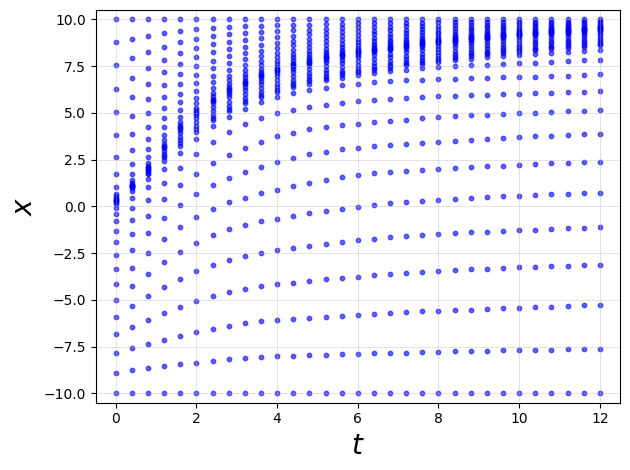

显示最终自适应采样点: 992个

迭代训练完成！


In [18]:
# 执行迭代训练
print("开始执行迭代训练...")
trained_model, sampling_history = iterative_training_with_adaptive_sampling(
    initial_epochs=3000,      # 初始训练轮数
    adaptive_epochs=3500,     # 每次自适应后的训练轮数
    num_iterations=2,         # 迭代次数
    mmpde_training_epochs=500 # MMPDE训练轮数
)

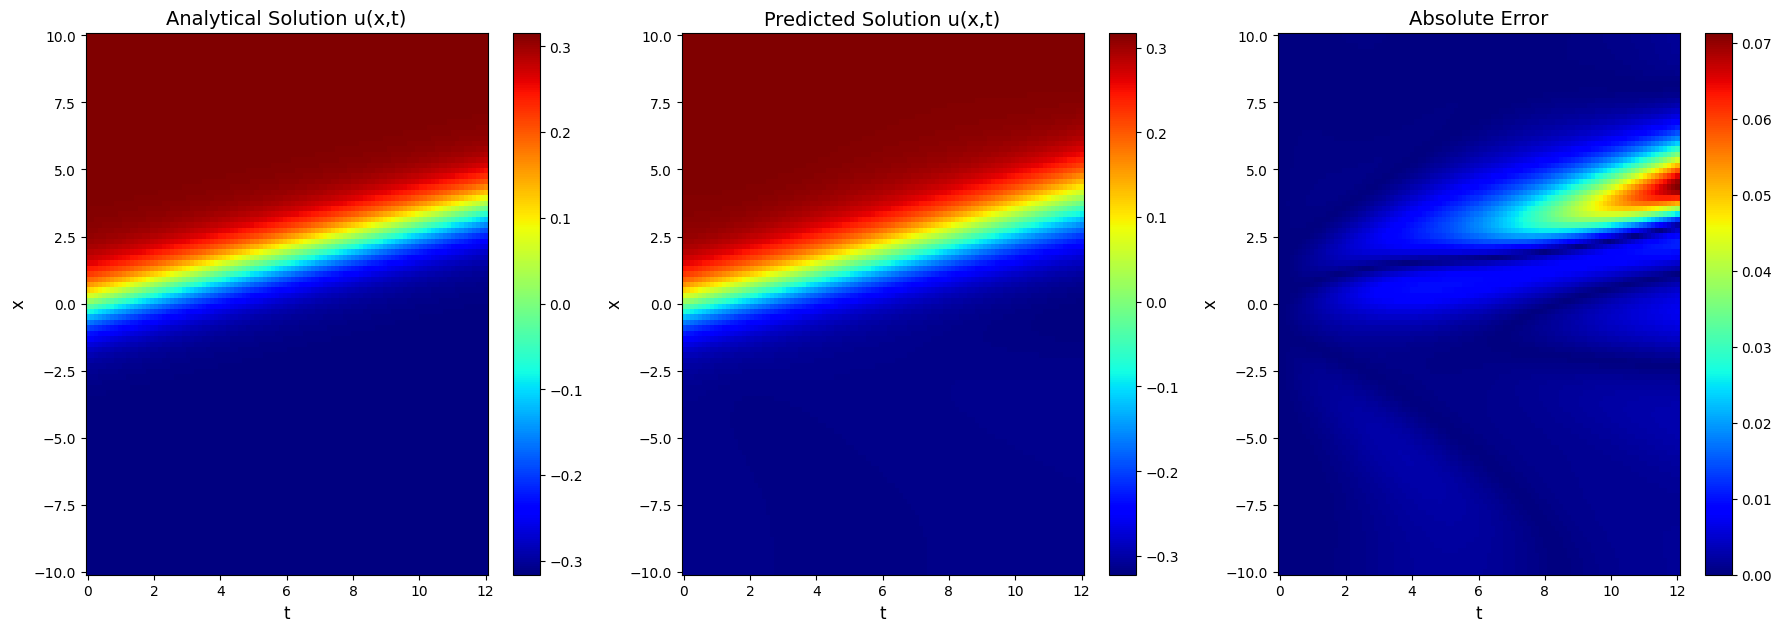

u的L2误差: 0.009454
v的L2误差: 0.002789


In [21]:
# 修改可视化部分 - 更新网格范围
# 创建网格点
nx, nt = 100, 100
x = torch.linspace(-10, 10, nx).reshape(-1, 1)  # x范围[-10,10]
t = torch.linspace(0, 12, nt).reshape(-1, 1)   # t范围[0,12]

X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing='ij')

X_flat = X.reshape(-1, 1)
T_flat = T.reshape(-1, 1)

# 组合输入
X_test = torch.cat([T_flat, X_flat], dim=1)

# 模型预测
with torch.no_grad():
    outputs_pred = trained_model(X_test)
    u_pred = outputs_pred[:, 0:1].reshape(nx, nt).detach().numpy()
    v_pred = outputs_pred[:, 1:2].reshape(nx, nt).detach().numpy()

# 解析解
u_exact = analytical_solution(T_flat, X_flat).reshape(nx, nt).detach().numpy()
v_exact = analytical_solution_v(T_flat, X_flat).reshape(nx, nt).detach().numpy()

# 计算误差
u_error = np.abs(u_pred - u_exact)
v_error = np.abs(v_pred - v_exact)

# 显示热图对比（现在显示u和v）
plt.figure(figsize=(18, 12))

# u的对比
plt.subplot(231)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_exact, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Analytical Solution u(x,t)', fontsize=14)

plt.subplot(232)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_pred, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Predicted Solution u(x,t)', fontsize=14)

plt.subplot(233)
im = plt.pcolormesh(T.numpy(), X.numpy(), u_error, cmap='jet', shading='auto')
plt.colorbar(im)
plt.xlabel('t', fontsize=12)
plt.ylabel('x', fontsize=12)
plt.title('Absolute Error', fontsize=14)

plt.tight_layout()
plt.show()

# 计算L2误差
total_u_l2_error = np.sqrt(np.mean(np.square(u_pred - u_exact)))
total_v_l2_error = np.sqrt(np.mean(np.square(v_pred - v_exact)))
print(f"u的L2误差: {total_u_l2_error:.6f}")
print(f"v的L2误差: {total_v_l2_error:.6f}")